# Test beersheba on MC 

In [1]:
import sys,os,os.path

from glob import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/gluster/data/next/software/IC_john/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
os.environ['ICTDIR']='/gluster/data/next/software/IC_john/'

from invisible_cities.io.dst_io        import load_dst, load_dsts
from invisible_cities.cities.beersheba import cut_over_Q
from invisible_cities.cities.beersheba import drop_isolated 
from invisible_cities.cities.beersheba import deconvolve_signal
from invisible_cities.reco.deconv_functions import deconvolution_input
from invisible_cities.reco.deconv_functions import InterpolationMethod
from invisible_cities.cities.beersheba import DeconvolutionMode
from invisible_cities.cities.beersheba          import CutType
from invisible_cities.database.load_db      import DataSiPM
from invisible_cities.database.load_db      import DetDB

from invisible_cities.evm.event_model        import HitEnergy

##
# FUNCTIONS
##
def raw_plotter(q, evt, pitch = 15.55, param = 'Q', title = None):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q[param], cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    if title is None:
        fig.suptitle(f"raw plot event {evt}")
    else:
        fig.suptitle(title)
    plt.show(fig)




ModuleNotFoundError: No module named 'invisible_cities'

In [ ]:
# select psf for the MC
psf_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/kr_20260N_full_fast_lowq_thr/data/remove_low_sipms/kr_202601_full/merged_psfs/kr_202601_full_full_25us.psf'

In [ ]:
# load in some data events --> FULLSIM
data_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/th_port1a_dep_202602_full/sophronia/'
data_path = glob(f'{data_path}*')
full_data = []
for i in tqdm(range(0, 100)):
    try:
        data          = load_dst(data_path[i], 'RECO', 'Events')
        data['event'] = i

        if ((data.Ec.sum() > 1.4) & (data.Ec.sum() < 1.8)):
            full_data.append(data)
    except Exception as e:
        print('e')

data = pd.concat(full_data)


 83%|████████▎ | 83/100 [00:03<00:00, 27.17it/s]

e


100%|██████████| 100/100 [00:04<00:00, 23.91it/s]


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,24,162790.358,0,141.307635,148.43705,1,135.875,216.325,0.0,0.0,845.175420,5.913043,796.111568,-1.0,0.003240,-1,-1.0
1,24,162790.358,0,141.307635,148.43705,1,151.425,231.875,0.0,0.0,845.175420,7.130435,960.016916,-1.0,0.003931,-1,-1.0
2,24,162790.358,0,141.307635,148.43705,1,166.975,231.875,0.0,0.0,845.175420,5.101449,686.841315,-1.0,0.002813,-1,-1.0
3,24,162790.358,0,141.307635,148.43705,1,120.325,216.325,0.0,0.0,848.478049,6.550725,344.915433,-1.0,0.001405,-1,-1.0
4,24,162790.358,0,141.307635,148.43705,1,120.325,231.875,0.0,0.0,848.478049,5.101449,268.606700,-1.0,0.001098,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830,24,162790.358,0,141.307635,148.43705,1,135.875,91.925,0.0,0.0,962.811165,7.710145,725.816150,-1.0,0.002900,-1,-1.0
831,24,162790.358,0,141.307635,148.43705,1,151.425,107.475,0.0,0.0,962.811165,5.913043,556.640954,-1.0,0.002233,-1,-1.0
832,24,162790.358,0,141.307635,148.43705,1,166.975,76.375,0.0,0.0,962.811165,5.797101,545.726428,-1.0,0.002179,-1,-1.0
833,24,162790.358,0,141.307635,148.43705,1,166.975,107.475,0.0,0.0,962.811165,11.130435,1047.794753,-1.0,0.004225,-1,-1.0


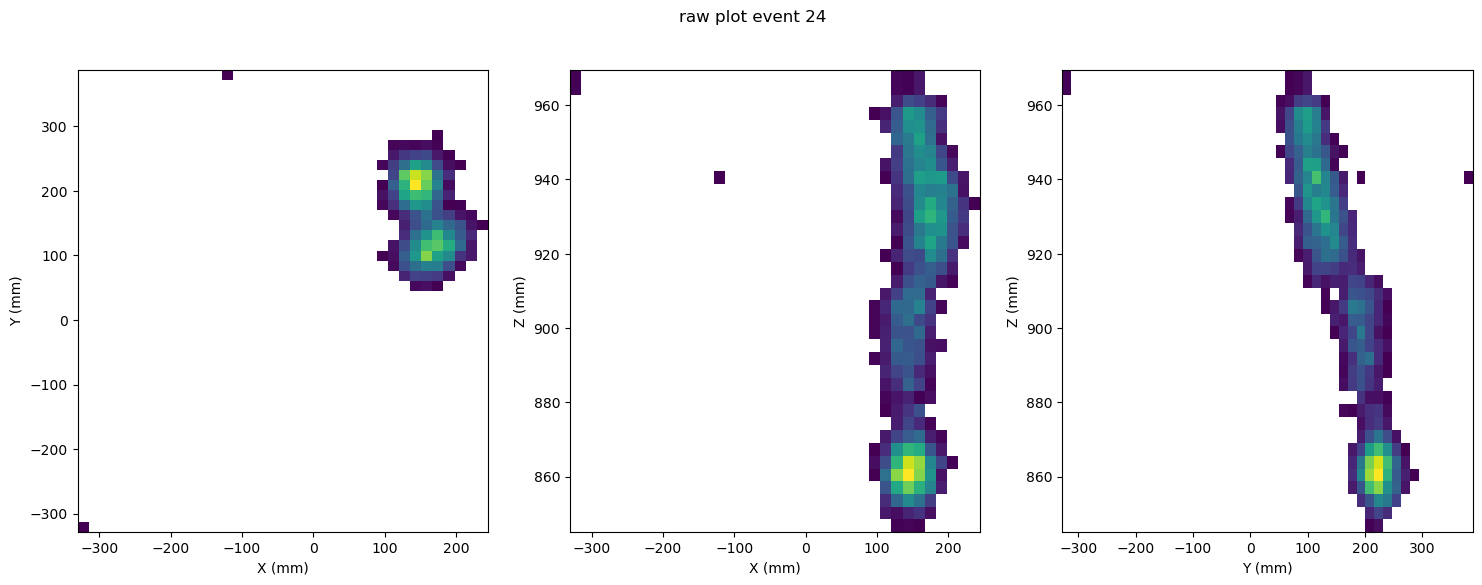

In [ ]:
# sanity check
N = 21
EOI = data[data.event == data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [ ]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16],#, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = psf_path,     
  e_cut            = 1e-6, #15 for 6mm  - 15 for 6mm
  n_iterations     = 150, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 1,  1],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 8e-3))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.

cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

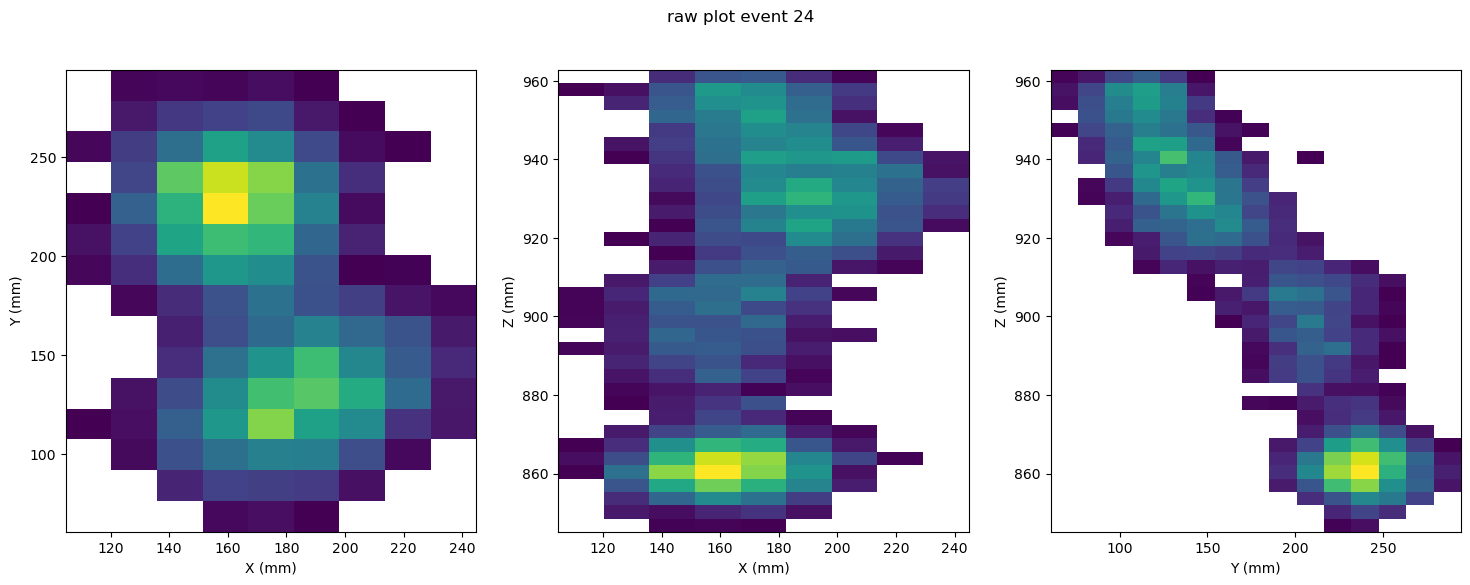

In [ ]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [7]:
# create beersheba object
detector_db = '/gluster/data/next/software/IC_john/IC/invisible_cities/database/localdb.NEXT100DB.sqlite3'
run_number = 0 
deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)

In [8]:
EOI_deco = deconvolver(EOI_drop)

In [9]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,24,0,137.375,220.075,845.175420,9.076192e-12,141.307635,148.43705
1,24,0,137.375,221.075,845.175420,1.583745e-11,141.307635,148.43705
2,24,0,137.375,222.075,845.175420,2.068416e-11,141.307635,148.43705
3,24,0,137.375,223.075,845.175420,2.022483e-11,141.307635,148.43705
4,24,0,137.375,224.075,845.175420,1.505868e-11,141.307635,148.43705
...,...,...,...,...,...,...,...,...
84181,24,0,169.375,102.075,962.811165,2.339929e-11,141.307635,148.43705
84182,24,0,169.375,103.075,962.811165,2.388469e-11,141.307635,148.43705
84183,24,0,169.375,104.075,962.811165,2.029931e-11,141.307635,148.43705
84184,24,0,169.375,105.075,962.811165,1.411698e-11,141.307635,148.43705


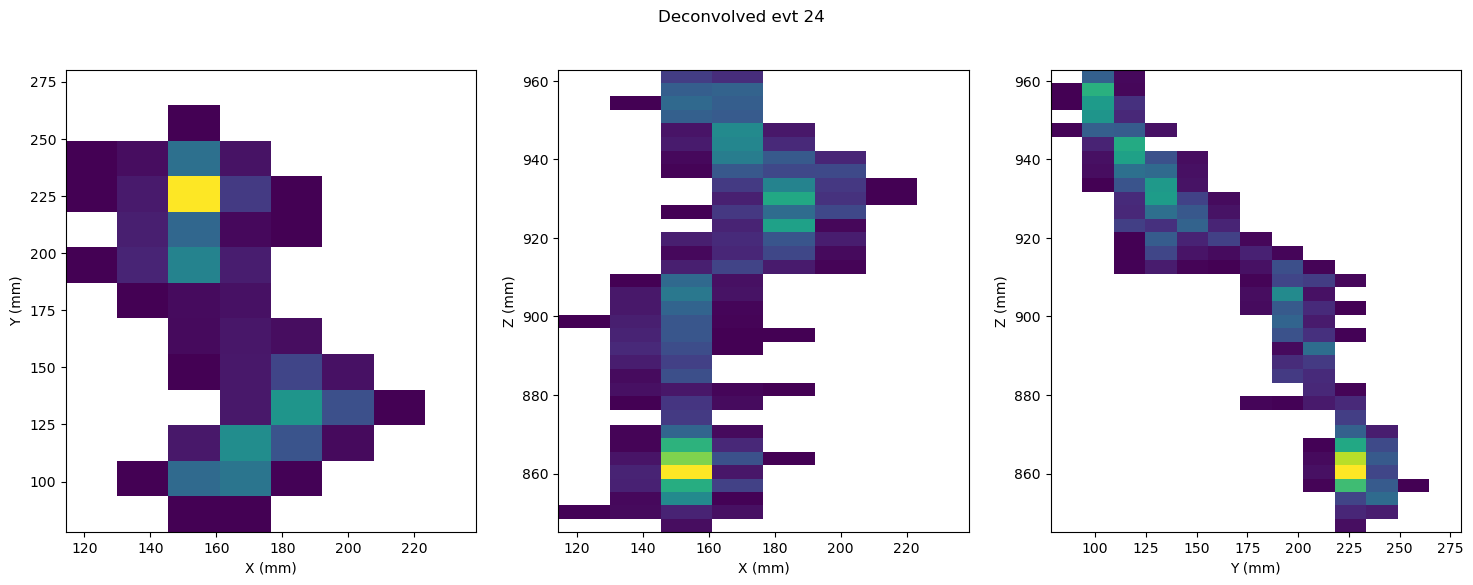

In [10]:
raw_plotter(EOI_deco, EOI_deco.event.unique()[0], param = 'E', title = f'Deconvolved evt {EOI_deco.event.unique()[0]}')

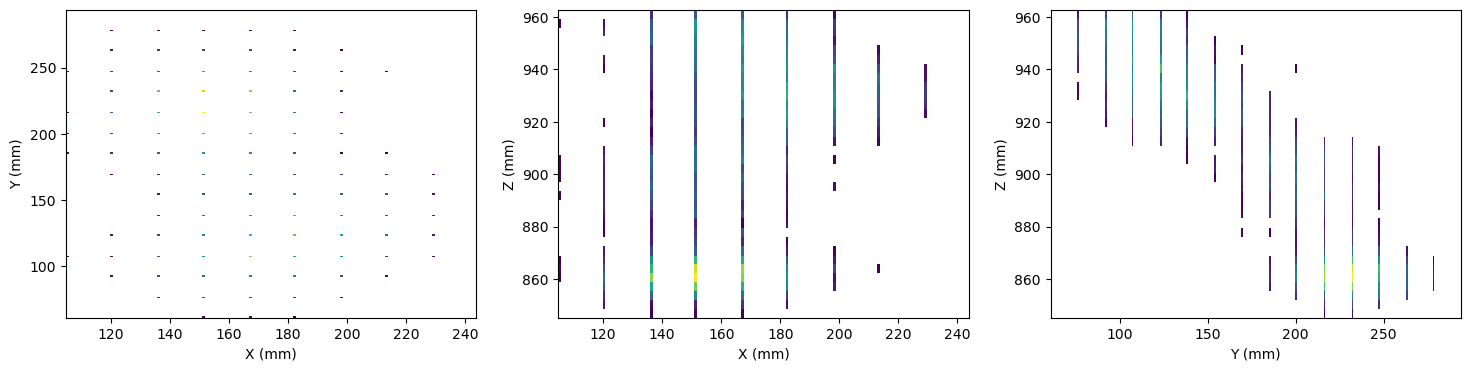

In [11]:
datatype = 'DATA'
pitch = 15.55

# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

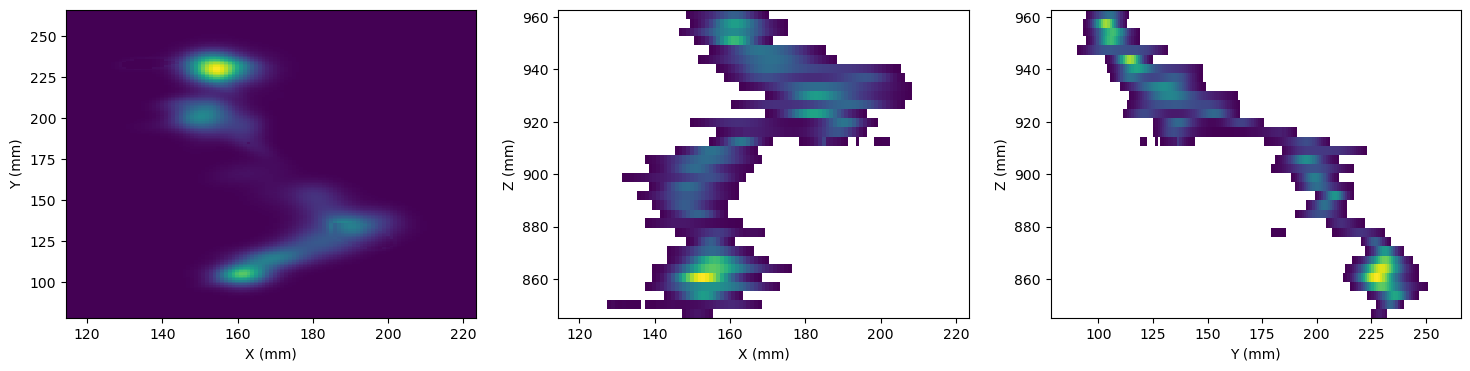

In [12]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

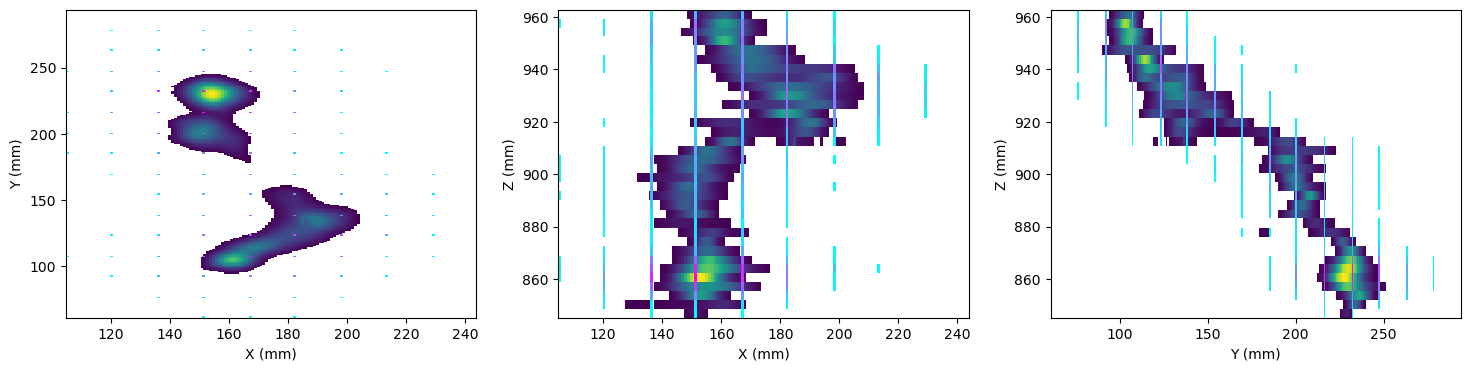

In [13]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [ ]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 600 
iteration_step   = 20
for i in range(10, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i}')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/130136_20260324
10


30
50
70
90
110
130
150
170
190
210
230
250
270
290
310
330
350
370
390
410
430
450
470
490
510
530
550
570


In [8]:
x = !pwd
print(x)

['/gluster/data/next/notebooks/john_books/year_of_horse_notebooks/beer_thekla_resolution']


In [17]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

### trying with the q_cut = 2 pes psf

In [96]:
PSF_2PEs = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15616/prod_psf/eutropia/040925/merged_psfs/final/040925_full_25us.psf'
deconv_params_['psf_fname'] = PSF_2PEs

from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 601
iteration_step   = 30
for i in range(30, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min()-pitch, EOI_drop.X.max()+pitch)# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min()-pitch, EOI_drop.Y.max()+pitch)# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} w/ 15616 (2 PEs) PSF')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/170220_20260302
30
60
90
120
150
180
210
240
270
300
330
360
390
420
450
480
510
540
570
600


In [97]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

### load in 15539 one bin data

In [98]:
kr_data_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15539/sophronia/run_15539_0001_ldc1_trg1.sophronia_1PEs.h5'
kr_data = load_dst(kr_data_path, 'RECO', 'Events')

In [99]:
# load in krypton map relevant to these events
# here we're going to use the krypton map that assumes no thresholds 
PSF_noPES = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15539/eutropia/PSF_15539_z100_xy1.0_130125.psf'

,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
694,2045,1.750084e+09,0,-77.330762,35.153424,1,-404.875,-263.725,0.0,0.0,64.508997,2.947154,17.255095,-1.0,-1.0,-1,-1.0
695,2045,1.750084e+09,0,-77.330762,35.153424,1,-482.625,-124.775,0.0,0.0,64.508997,2.888913,16.914104,-1.0,-1.0,-1,-1.0
696,2045,1.750084e+09,0,-77.330762,35.153424,1,-420.425,-62.575,0.0,0.0,64.508997,2.334365,13.667318,-1.0,-1.0,-1,-1.0
697,2045,1.750084e+09,0,-77.330762,35.153424,1,-389.325,-62.575,0.0,0.0,64.508997,2.115768,12.387468,-1.0,-1.0,-1,-1.0
698,2045,1.750084e+09,0,-77.330762,35.153424,1,-373.775,-155.875,0.0,0.0,64.508997,2.089278,12.232373,-1.0,-1.0,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
962,2045,1.750084e+09,0,-77.330762,35.153424,1,381.175,214.325,0.0,0.0,64.508997,2.073942,12.142586,-1.0,-1.0,-1,-1.0
963,2045,1.750084e+09,0,-77.330762,35.153424,1,396.725,307.625,0.0,0.0,64.508997,3.763338,22.033718,-1.0,-1.0,-1,-1.0
964,2045,1.750084e+09,0,-77.330762,35.153424,1,443.375,198.775,0.0,0.0,64.508997,2.914721,17.065206,-1.0,-1.0,-1,-1.0
965,2045,1.750084e+09,0,-77.330762,35.153424,1,474.475,214.325,0.0,0.0,64.508997,2.188171,12.811378,-1.0,-1.0,-1,-1.0


/tmp/ipykernel_1499404/3337667901.py:42: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
/tmp/ipykernel_1499404/3337667901.py:47: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);


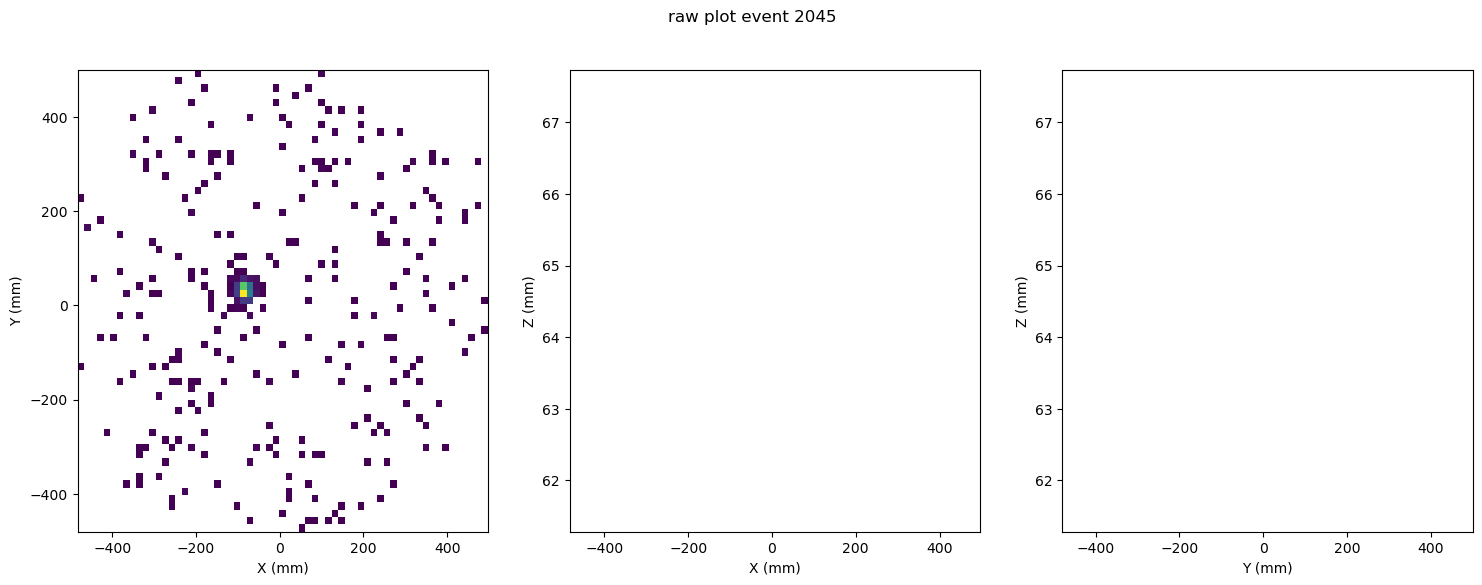

In [104]:
# sanity check
N = 2
EOI = kr_data[kr_data.event == kr_data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [133]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16],#, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = PSF_noPES,     
  e_cut            = 8e-3, #15 for 6mm  - 15 for 6mm
  n_iterations     = 25, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 1,  1],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 8e-3))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.

cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

/tmp/ipykernel_1499404/3337667901.py:42: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
/tmp/ipykernel_1499404/3337667901.py:47: UserWarning: Attempting to set identical bottom == top == 64.508996875 results in singular transformations; automatically expanding.
  axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);


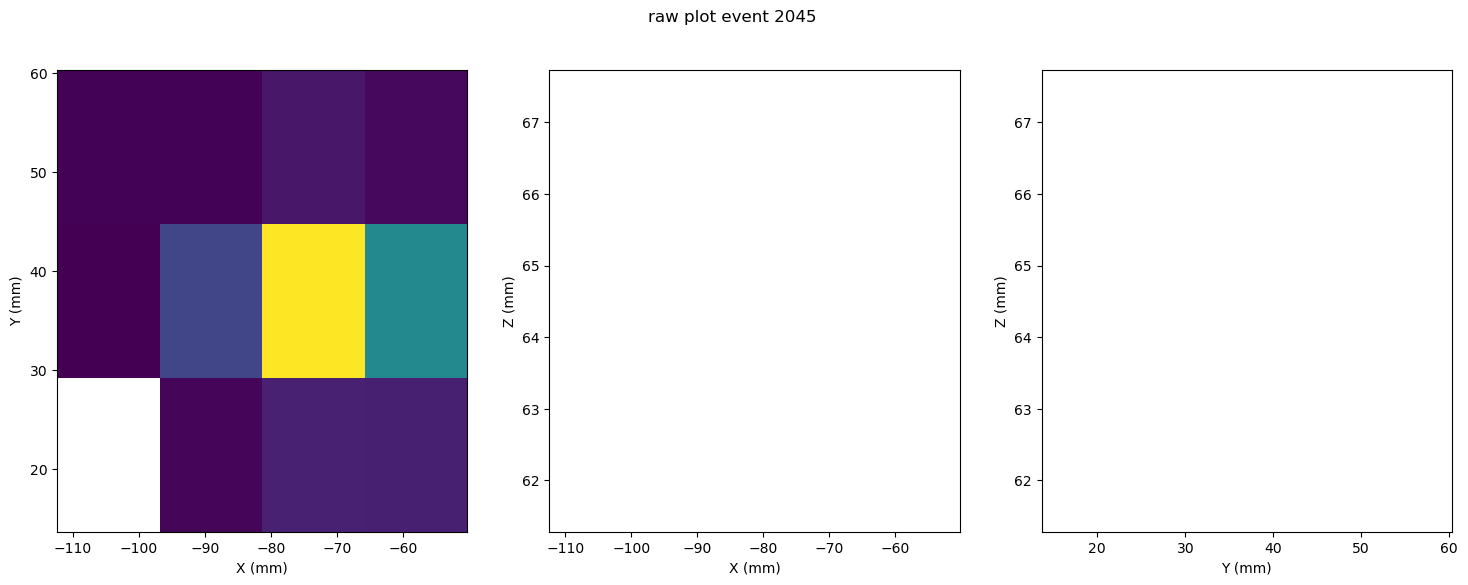

In [134]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [138]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated folder {path}')

# for gif creation
png_list = []

n_iterations_max = 601
iteration_step   = 30
for i in range(30, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max())# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max())# + pitch, pitch)
    zz = EOI_deco.Z.unique()
    
    EOI_deco.E = np.abs(EOI_deco.E)
    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.0001);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    #axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.0001);
    #if (datatype == 'MC'):
    #    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    #axes[1].set_xlabel('X (mm)');
    #axes[1].set_ylabel('Z (mm)');

    #axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
    #if (datatype == 'MC'):
    #    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    #axes[2].set_xlabel('Y (mm)');
    #axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    #axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    #if (datatype == 'MC'):
    #    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    #axes[1].set_xlabel('X (mm)');
    #axes[1].set_ylabel('Z (mm)');

    #axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
    #if (datatype == 'MC'):
    #    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    #axes[2].set_xlabel('Y (mm)');
    #axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} rebinned in Z')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated folder gif_images/172235_20260302
30
60
90
120
150
180
210
240
270
300
330
360
390
420
450
480
510
540
570
600


In [139]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=1, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

In [140]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,2045,0,-82.625,34.075,64.508997,0.015980,-77.330762,35.153424
1,2045,0,-82.625,35.075,64.508997,0.025852,-77.330762,35.153424
2,2045,0,-82.625,36.075,64.508997,0.032270,-77.330762,35.153424
3,2045,0,-82.625,37.075,64.508997,0.031983,-77.330762,35.153424
4,2045,0,-82.625,38.075,64.508997,0.025598,-77.330762,35.153424
...,...,...,...,...,...,...,...,...
121,2045,0,-73.625,31.075,64.508997,0.036932,-77.330762,35.153424
122,2045,0,-73.625,32.075,64.508997,0.037542,-77.330762,35.153424
123,2045,0,-73.625,33.075,64.508997,0.030183,-77.330762,35.153424
124,2045,0,-73.625,34.075,64.508997,0.020205,-77.330762,35.153424
